# Imports

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve, auc
)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)


# Load your preprocessed data

In [28]:
X_train_normal = pd.read_csv("X_train_normal.csv")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").squeeze()  # convert to Series

X_train_normal.shape, X_test.shape, y_test.shape


((199020, 30), (85443, 30), (85443,))

# Train Isolation Forest on normal data

Key settings:

contamination = expected fraud rate (use the true rate from dataset)

random_state = reproducibility

In [3]:
fraud_rate = y_test.mean()  # approximate fraud fraction in test set
fraud_rate


0.0017321489179921118

In [4]:
iso = IsolationForest(
    n_estimators=300,
    contamination=fraud_rate,   # expected fraction of anomalies
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train_normal)


IsolationForest(contamination=0.0017321489179921118, n_estimators=300,
                n_jobs=-1, random_state=42)

# Get anomaly scores + predictions

Isolation Forest outputs:

decision_function: higher = more normal

score_samples: lower = more anomalous

We’ll convert to an “anomaly score” where higher = more anomalous.

In [5]:
normality_score = iso.decision_function(X_test)
anomaly_score = -normality_score  # flip so higher means more anomalous


Now predict:
IsolationForest predicts:

1 = inlier (normal)

-1 = outlier (anomaly)

We map to:

0 = normal

1 = fraud/anomaly

In [6]:
pred_raw = iso.predict(X_test)
y_pred = np.where(pred_raw == -1, 1, 0)


# Evaluate (Confusion Matrix + Report)

In [7]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[85167,   128],
       [  113,    35]])

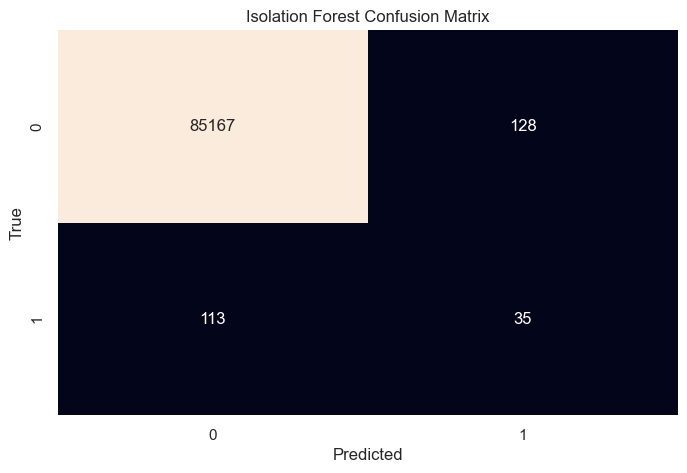

In [8]:
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [9]:
print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.9987    0.9985    0.9986     85295
           1     0.2147    0.2365    0.2251       148

    accuracy                         0.9972     85443
   macro avg     0.6067    0.6175    0.6118     85443
weighted avg     0.9973    0.9972    0.9972     85443



What to look at (very important):

Recall for fraud (how many frauds you catch)

Precision for fraud (how many flagged are actually fraud)

False positives (normal flagged as fraud) is always a trade-off

# ROC-AUC and PR-AUC (more meaningful for imbalanced data)

ROC-AUC using anomaly scores

In [10]:
roc = roc_auc_score(y_test, anomaly_score)
roc


0.9482997799370388

Precision-Recall curve + PR-AUC (often better for fraud detection)

In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, anomaly_score)
pr_auc = auc(recall, precision)
pr_auc


0.1156030388751146

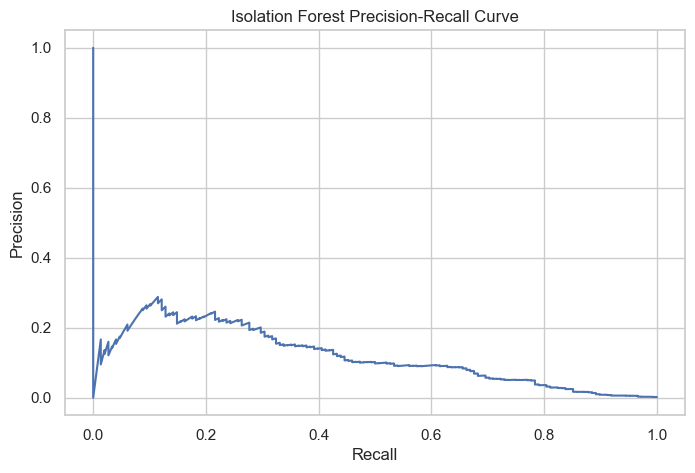

In [23]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Isolation Forest Precision-Recall Curve")
plt.show()


# Threshold Tuning

Isolation Forest chooses threshold automatically based on contamination.
But in real fraud detection, you choose a threshold based on business trade-offs.

In [24]:
thresholds_to_try = np.quantile(anomaly_score, [0.90, 0.95, 0.98, 0.99, 0.995])

results = []
for t in thresholds_to_try:
    y_pred_t = (anomaly_score >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    precision_t = tp / (tp + fp) if (tp + fp) else 0
    recall_t = tp / (tp + fn) if (tp + fn) else 0
    results.append((t, precision_t, recall_t, fp, tp))

results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "FalsePositives", "TruePositives"])
results_df
# Choose a single threshold for deployment:
# Flag the top ~fraud_rate fraction as anomalies (consistent with expected fraud rate)
iso_threshold = np.quantile(anomaly_score, 1 - fraud_rate)

iso_threshold

import json

thresholds = {"iso_threshold": float(iso_threshold)}

with open("thresholds.json", "w") as f:
    json.dump(thresholds, f)

print("Saved thresholds.json with iso_threshold")


Saved thresholds.json with iso_threshold


Isolation Forest Summary-

    Trained on normal transactions only (unsupervised)

    Produces anomaly scores for each transaction

    Evaluated using confusion matrix, ROC-AUC, and PR-AUC

    Tuned decision threshold to trade off precision vs recall

In [25]:
pd.DataFrame({
    "row_id": np.arange(len(y_test)),
    "y_true": y_test.values,
    "iso_anomaly_score": anomaly_score
}).to_csv("iso_scores.csv", index=False)


In [26]:
import joblib
joblib.dump(iso, "isolation_forest.pkl")


['isolation_forest.pkl']